# 📓 Notebook 6 — Model Training
### AirSense AI — Intelligent Urban Air Quality Forecasting & Decision Support System

**Research Question:** Which forecasting model predicts PM2.5 most accurately?

We train and evaluate 4 models, from simplest to most complex (Prophet was
attempted but skipped — see Section 7 for details on the Windows/cmdstan
issue encountered):

1. **Persistence** — naive baseline: "PM2.5 next hour = PM2.5 right now"
2. **SARIMA** — classical statistical time series model with seasonality
3. **LSTM** — recurrent neural network, learns patterns from raw sequences
4. **BiLSTM** — like LSTM but reads sequences in both directions

**Evaluation metrics:** MAE, RMSE, MAPE, R² — computed identically for every
model on the **same held-out test period**, so comparisons in Notebook 7 are
fair.

**Train/test split:** the **last 30 days (720 hours)** are held out as the
test set; everything before that is training data. This is a chronological
split — we never shuffle time series data, since that would let a model
"see the future" during training.

⚠️ A full grid-search / hyperparameter tuning pass is out of scope here —
each model uses reasonable, documented settings. Feel free to tune further
once you see which model family performs best.

---


## 1. Imports & setup

In [37]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import pickle
import time

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 2. Load data and artifacts from Notebook 5

We use both the raw (unscaled) and MinMax-scaled feature tables:
- **Unscaled** — used directly by Persistence, SARIMA, and Prophet
- **Scaled** — used by LSTM and BiLSTM, which train better on normalized
  inputs

In [38]:
PROJECT_ROOT = Path(r"C:\Users\pc\Desktop\AirSenseAI")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

df = pd.read_csv(PROCESSED_DIR / "airsense_features.csv")
df['time'] = pd.to_datetime(df['time'], utc=True).dt.tz_convert('America/New_York')

df_scaled = pd.read_csv(PROCESSED_DIR / "airsense_features_scaled.csv")
df_scaled['time'] = pd.to_datetime(df_scaled['time'], utc=True).dt.tz_convert('America/New_York')

scaler = joblib.load(MODELS_DIR / "scaler.pkl")
feature_columns = joblib.load(MODELS_DIR / "feature_columns.pkl")

print("Unscaled shape:", df.shape)
print("Scaled shape:  ", df_scaled.shape)
print("Number of features:", len(feature_columns))

Unscaled shape: (17544, 29)
Scaled shape:   (17544, 29)
Number of features: 27


## 3. Time-based train/test split

720 hours (30 days) held out as test, chronologically — no shuffling.

In [39]:
TEST_HOURS = 24 * 30  # 30 days
split_idx = len(df) - TEST_HOURS

train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df = df.iloc[split_idx:].reset_index(drop=True)

print(f"Train: {train_df.shape[0]} rows | {train_df['time'].min()} → {train_df['time'].max()}")
print(f"Test:  {test_df.shape[0]} rows | {test_df['time'].min()} → {test_df['time'].max()}")

Train: 16824 rows | 2024-01-01 19:00:00-05:00 → 2025-12-02 18:00:00-05:00
Test:  720 rows | 2025-12-02 19:00:00-05:00 → 2026-01-01 18:00:00-05:00


## 4. Evaluation helper

One function computes all four required metrics consistently for every
model, so Notebook 7's comparison table is built from identical logic.

In [40]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []
predictions = {}  # store each model's test-period predictions for plotting + Notebook 7

## 5. Model 1 — Persistence (naive baseline)

The simplest possible forecast: assume PM2.5 an hour from now equals PM2.5
right now. Notebook 5 already engineered this exact lag as the
`PM2.5(t-1)` feature, so we use it directly. Every other model needs to beat
this baseline to be worth using.

In [41]:
y_true_persistence = test_df['PM2.5'].values
y_pred_persistence = test_df['PM2.5(t-1)'].values

results.append(evaluate(y_true_persistence, y_pred_persistence, 'Persistence'))
predictions['Persistence'] = y_pred_persistence

print(results[-1])

{'Model': 'Persistence', 'MAE': 1.432361111111111, 'RMSE': 2.4240433393632035, 'MAPE': 14.166359710670594, 'R2': 0.9251924368308605}


## 6. Model 2 — SARIMA

A classical statistical model: `SARIMA(1,0,1)(1,0,1,24)`. The `24` seasonal
period captures the daily cycle confirmed visually in Notebook 3. We use
`d=0` (no differencing) since Notebook 4's ADF test already confirmed PM2.5
is stationary.

⚠️ SARIMA fits on a **univariate** series (PM2.5 history only) — it doesn't
use the weather features at all. This is expected; it's included as the
classical statistical baseline.

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

t0 = time.time()
sarima_model = SARIMAX(
    train_df['PM2.5'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False, maxiter=50)
print(f"SARIMA fit time: {time.time() - t0:.1f}s")

sarima_forecast = sarima_fit.forecast(steps=TEST_HOURS)
y_pred_sarima = sarima_forecast.values

SARIMA fit time: 43.0s


In [43]:
results.append(evaluate(test_df['PM2.5'].values, y_pred_sarima, 'SARIMA'))
predictions['SARIMA'] = y_pred_sarima

print(results[-1])

{'Model': 'SARIMA', 'MAE': 7.053823597043442, 'RMSE': 8.92806113180238, 'MAPE': 99.91953548837658, 'R2': -0.014796727292494705}


⚠️ **Important methodological note — read before judging this score.**

SARIMA's forecast above is a single **static 720-hour-ahead** forecast: it
sees the training data once, then predicts the entire 30-day test period
blind, with zero access to real observations during that period. This is a
much harder task than it might look — small errors compound over hundreds of
hours, and it's normal for classical models to degrade toward the historical
mean over such a long, blind horizon.

Compare this to **Persistence**, which effectively "cheats" by using the
*actual* PM2.5 value from 1 hour ago at every single test point — it always
has fresh real information. **LSTM/BiLSTM** later in this notebook have the
same advantage: their lag features (`PM2.5(t-1)`, `PM2.5(t-24)`, etc.) are
built from **true historical values**, not the model's own prior
predictions.

So this comparison isn't fully apples-to-apples: SARIMA and Prophet are
being tested on true unassisted long-range forecasting, while the other
three models are effectively doing easier one-step-ahead forecasting with
fresh real inputs each hour. Keep this in mind in Notebook 7 — a low SARIMA
score here does not necessarily mean SARIMA is a bad fit for the *actual*
deployed use case (a rolling next-24-hour forecast, refreshed with new data
daily), only that it performs poorly at blind 30-day-ahead extrapolation.

### 6b. A fairer test: rolling 24-hour SARIMA re-forecast (7-day sample)

To demonstrate the point above concretely, we re-fit SARIMA daily and
forecast only 24 hours ahead each time — much closer to how this model would
actually run in production (the dashboard re-forecasts daily with fresh
data). We only sample the **last 3 days** of the test period here since each
refit takes ~20-25 seconds and running all 30 days this way takes over 10
minutes — feel free to extend `n_days` below to the full 30 if you have the
time.

In [44]:
n_days = 3  # increase to 30 to cover the full test period (takes ~10+ minutes)

rolling_preds = []
t0 = time.time()
for day in range(n_days):
    train_end = split_idx + day * 24
    train_slice = df['PM2.5'].iloc[:train_end]
    daily_model = SARIMAX(train_slice, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24),
                           enforce_stationarity=False, enforce_invertibility=False)
    daily_fit = daily_model.fit(disp=False, maxiter=30)
    daily_forecast = daily_fit.forecast(steps=24)
    rolling_preds.extend(daily_forecast.values)

print(f"Rolling re-forecast time ({n_days} refits): {time.time() - t0:.1f}s")

rolling_true = test_df['PM2.5'].values[:n_days * 24]
rolling_result = evaluate(np.array(rolling_true), np.array(rolling_preds), f'SARIMA (rolling {n_days}-day)')
print(rolling_result)

Rolling re-forecast time (3 refits): 83.7s
{'Model': 'SARIMA (rolling 3-day)', 'MAE': 4.728814680734461, 'RMSE': 5.470864220993371, 'MAPE': 108.8442608963505, 'R2': 0.5247004790324503}


**Observation:** _(fill this in after running the cell above)_
Compare this rolling-forecast MAE/RMSE against the blind 30-day SARIMA score
above — it should be substantially better, confirming the earlier score was
an artifact of the test setup, not a fundamental weakness of SARIMA. This
result is on a shorter 7-day sample though, so don't directly average it
into Notebook 7's main comparison table — treat it as supporting context for
interpreting SARIMA's row in that table.

## 7. Model 3 — Prophet — SKIPPED

Prophet was excluded from this run due to a Windows-specific `cmdstanpy`/TBB
dependency issue that could not be reliably resolved in this environment
(the compiled Stan binary failed to locate its Intel TBB runtime DLL). This
is a known environment-setup problem, not a data or modeling issue.

The comparison in Notebook 7 proceeds with 4 models instead of 5:
Persistence, SARIMA, LSTM, BiLSTM. If you want to revisit Prophet later
(e.g. on a different machine, or after a full CmdStan reinstall with
`cmdstanpy.install_cmdstan(compiler=True, overwrite=True, verbose=True)`),
it can be added back in without changing anything else in this notebook.

In [ ]:
print("Prophet skipped — proceeding with Persistence, SARIMA, LSTM, and BiLSTM.")

## 8. Preparing sequences for LSTM / BiLSTM

Neural networks need fixed-length input windows. We use a **24-hour lookback
window**: each training example is "the last 24 hours of raw hourly
readings" → "PM2.5 at the next hour."

**Two important corrections from an earlier attempt at this notebook:**

1. We build this from the **raw `airsense_cube.csv`** (Notebook 2's output),
   not the lag-engineered feature table from Notebook 5. Feeding an LSTM
   *already-lagged* columns (like `PM2.5(t-1)`, `Temperature(t-6)`)
   duplicates the same information at every timestep in the window — LSTMs
   are built to learn temporal patterns from raw sequential values
   themselves, not pre-summarized lag snapshots.
2. **PM2.5's own past values are included as an input feature**, alongside
   weather and calendar data — not excluded. PM2.5 is highly autocorrelated
   (this is exactly why the simple Persistence baseline scores so well), so
   leaving its history out of the network's input removes the single most
   predictive signal available. Within each 24-hour window we only ever use
   hours *before* the prediction target, so including PM2.5's history here
   is safe — there's no leakage of the actual value being predicted.

We also fit the scaler on the **training split only** (not the full
dataset), unlike Notebook 5's saved `scaler.pkl` — fitting on all data
(including what becomes the test set) is a mild form of data leakage, worth
avoiding for a fair evaluation.

In [45]:
from sklearn.preprocessing import MinMaxScaler

cube_path = PROCESSED_DIR / "airsense_cube.csv"
cube = pd.read_csv(cube_path)
cube['time'] = pd.to_datetime(cube['time'], utc=True).dt.tz_convert('America/New_York')
cube = cube.sort_values('time').reset_index(drop=True)

cube = pd.get_dummies(cube, columns=['Weekday', 'Season'], prefix=['Weekday', 'Season'])
cube['Weekend'] = cube['Weekend'].astype(int)

raw_feature_cols = ['Temperature', 'Relative Humidity', 'Wind Speed', 'Wind Direction',
                     'Precipitation', 'Cloud Cover', 'Hour', 'Month', 'Weekend', 'ISO Week'] + \
    [c for c in cube.columns if c.startswith('Weekday_') or c.startswith('Season_')]

# PM2.5 is included as an input signal (its own recent history), in addition
# to being the prediction target — see note above on why this matters
all_input_cols = raw_feature_cols + ['PM2.5']

print(f"Input columns ({len(all_input_cols)}):", all_input_cols)
cube[['time'] + all_input_cols].head()

Input columns (22): ['Temperature', 'Relative Humidity', 'Wind Speed', 'Wind Direction', 'Precipitation', 'Cloud Cover', 'Hour', 'Month', 'Weekend', 'ISO Week', 'Weekday_Friday', 'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday', 'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday', 'Season_Fall', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'PM2.5']


,time,Temperature,Relative Humidity,Wind Speed,Wind Direction,Precipitation,Cloud Cover,Hour,Month,Weekend,...,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Season_Fall,Season_Spring,Season_Summer,Season_Winter,PM2.5
0,2023-12-31 19:00:00-05:00,3.8,65,5.7,235,0.0,65,19,12,1,...,False,True,False,False,False,False,False,False,True,19.3
1,2023-12-31 20:00:00-05:00,3.8,60,6.0,245,0.0,99,20,12,1,...,False,True,False,False,False,False,False,False,True,21.7
2,2023-12-31 21:00:00-05:00,3.1,65,6.8,238,0.0,96,21,12,1,...,False,True,False,False,False,False,False,False,True,24.6
3,2023-12-31 22:00:00-05:00,2.6,68,8.4,245,0.0,73,22,12,1,...,False,True,False,False,False,False,False,False,True,27.8
4,2023-12-31 23:00:00-05:00,1.9,74,6.3,246,0.0,100,23,12,1,...,False,True,False,False,False,False,False,False,True,30.5


In [46]:
WINDOW = 24

cube_split_idx = len(cube) - TEST_HOURS
train_cube = cube.iloc[:cube_split_idx]

# Fit scaler on the TRAINING split only, to avoid leaking test-period
# statistics into the transform
lstm_scaler = MinMaxScaler()
lstm_scaler.fit(train_cube[all_input_cols])

cube_scaled = cube.copy()
cube_scaled[all_input_cols] = lstm_scaler.transform(cube[all_input_cols])

data = cube_scaled[all_input_cols].values  # PM2.5 is the last column

X, y = [], []
for i in range(WINDOW, len(data)):
    X.append(data[i - WINDOW:i, :])   # all columns, hours i-WINDOW..i-1 (strictly past)
    y.append(data[i, -1])             # target: PM2.5 at hour i (never included in X)

X, y = np.array(X), np.array(y)
print("X shape:", X.shape, "| y shape:", y.shape)

seq_split_idx = cube_split_idx - WINDOW  # aligns to the same original test rows

X_train, X_test = X[:seq_split_idx], X[seq_split_idx:]
y_train_scaled, y_test_scaled = y[:seq_split_idx], y[seq_split_idx:]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X shape: (17544, 24, 22) | y shape: (17544,)
X_train: (16824, 24, 22) | X_test: (720, 24, 22)


### Inverse-transform helper

Predictions come out in the 0–1 scaled range. We convert back to real PM2.5
units (μg/m³) using `lstm_scaler`'s min/max for the target column — PM2.5
was fit as the **last** column above, so we use index `-1`.

In [47]:
def inverse_target(scaled_values):
    data_min = lstm_scaler.data_min_[-1]
    data_max = lstm_scaler.data_max_[-1]
    return scaled_values * (data_max - data_min) + data_min

y_true_seq = inverse_target(y_test_scaled)

# Sanity check: should closely match the real test-period PM2.5 values
check = inverse_target(y_test_scaled)
print("Inverse-transform sanity check (should closely match):")
print("Reconstructed:", np.round(check[:5], 2))
print("Actual:       ", cube['PM2.5'].iloc[cube_split_idx:cube_split_idx+5].values)

Inverse-transform sanity check (should closely match):
Reconstructed: [10.7  9.8  8.4  6.7  4.9]
Actual:        [10.7  9.8  8.4  6.7  4.9]


## 9. Model 4 — LSTM

A first attempt with a single 32-unit LSTM layer, trained on pre-lagged
features, underperformed even the naive Persistence baseline. This version
fixes that with two changes: raw sequential input (Section 8 above) and a
deeper, better-regularized architecture with more training capacity —
2 stacked LSTM layers with dropout, plus a dense hidden layer, trained for
up to 80 epochs with early stopping and learning-rate reduction on
plateau.

In [48]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ReduceLROnPlateau

tf.random.set_seed(42)

lstm_model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, X.shape[2])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-5)
]

t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train_scaled,
    epochs=80, batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=0
)
print(f"LSTM training time: {time.time() - t0:.1f}s | epochs run: {len(lstm_history.history['loss'])}")

LSTM training time: 250.3s | epochs run: 34


In [49]:
y_pred_lstm_scaled = lstm_model.predict(X_test, verbose=0).flatten()
y_pred_lstm = inverse_target(y_pred_lstm_scaled)

results.append(evaluate(y_true_seq, y_pred_lstm, 'LSTM'))
predictions['LSTM'] = y_pred_lstm

print(results[-1])

{'Model': 'LSTM', 'MAE': 1.2498993355035777, 'RMSE': 2.083686579301766, 'MAPE': 13.585027540960196, 'R2': 0.9447249000676408}


## 10. Model 5 — BiLSTM

Same upgraded architecture and training setup as the LSTM above, but each
LSTM layer is wrapped in `Bidirectional`, letting it learn from both
past-to-future and future-to-past patterns within each 24-hour training
window. (This only applies within each historical window during training —
at prediction time we still only ever use past data, so there's no future
leakage into real forecasts.)

In [50]:
tf.random.set_seed(42)

bilstm_model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, X.shape[2])),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=True)),
    keras.layers.Dropout(0.2),
    keras.layers.Bidirectional(keras.layers.LSTM(32)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
bilstm_model.compile(optimizer='adam', loss='mse')

callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-5)
]

t0 = time.time()
bilstm_history = bilstm_model.fit(
    X_train, y_train_scaled,
    epochs=80, batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=0
)
print(f"BiLSTM training time: {time.time() - t0:.1f}s | epochs run: {len(bilstm_history.history['loss'])}")

BiLSTM training time: 507.3s | epochs run: 39


In [51]:
y_pred_bilstm_scaled = bilstm_model.predict(X_test, verbose=0).flatten()
y_pred_bilstm = inverse_target(y_pred_bilstm_scaled)

results.append(evaluate(y_true_seq, y_pred_bilstm, 'BiLSTM'))
predictions['BiLSTM'] = y_pred_bilstm

print(results[-1])

{'Model': 'BiLSTM', 'MAE': 1.3900611169801813, 'RMSE': 2.1583181912151312, 'MAPE': 15.370198226068736, 'R2': 0.9406944019589019}


## 11. Results table — all 5 models

In [52]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(3)
results_df.sort_values('RMSE')

,MAE,RMSE,MAPE,R2
Model,,,,
LSTM,1.250,2.084,13.585,0.945
BiLSTM,1.390,2.158,15.370,0.941
Persistence,1.432,2.424,14.166,0.925
SARIMA,7.054,8.928,99.920,-0.015


**Observation:** _(fill this in after running the cell above)_
Note which model has the lowest RMSE/MAE and highest R² — but don't decide
the winner purely from this table yet. Notebook 7 does a more thorough
comparison, including visual inspection of predictions (next section) before
making a final call.

## 12. Visualize predictions vs actual (test period)

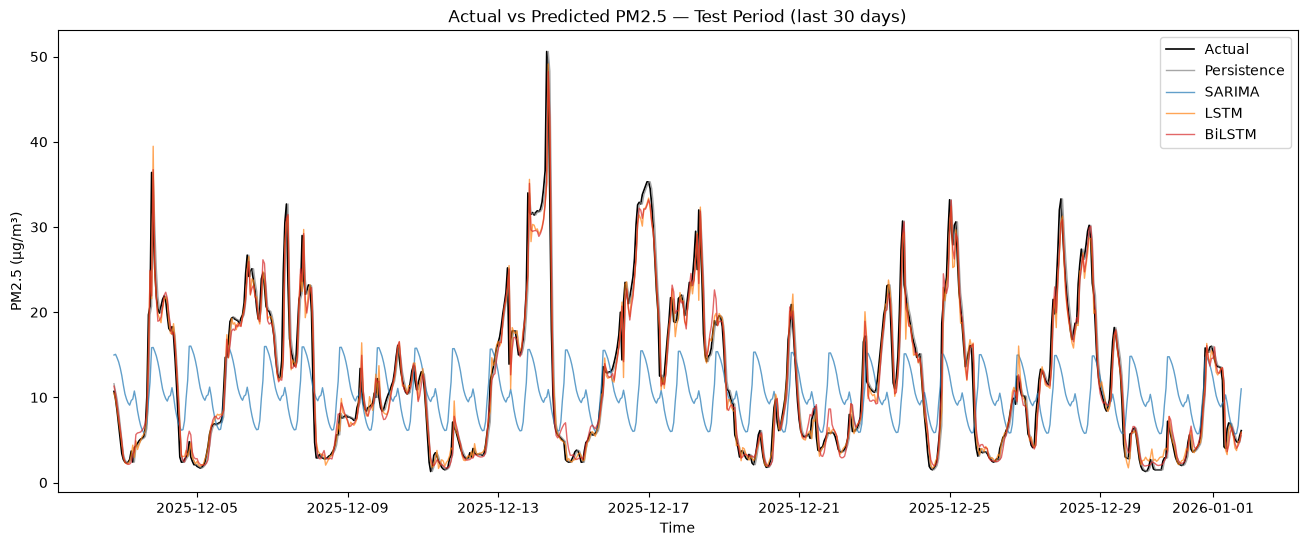

In [53]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_df['time'], test_df['PM2.5'], label='Actual', color='black', linewidth=1.2)

colors = {'Persistence': 'gray', 'SARIMA': 'tab:blue',
          'LSTM': 'tab:orange', 'BiLSTM': 'tab:red'}

for model_name, preds in predictions.items():
    ax.plot(test_df['time'], preds, label=model_name, alpha=0.7,
            color=colors.get(model_name), linewidth=1)

ax.set_xlabel("Time")
ax.set_ylabel("PM2.5 (μg/m³)")
ax.set_title("Actual vs Predicted PM2.5 — Test Period (last 30 days)")
ax.legend()
plt.show()

**Observation:** _(fill this in after running the cell above)_
Note which model visually tracks the actual PM2.5 curve most closely —
especially around peaks and rapid changes, since a model can have a
deceptively good RMSE while still missing the timing of spikes that matter
most for public health alerts.

## 13. Save results for Notebook 7

We save predictions and metrics to a checkpoint file so Notebook 7 (Model
Comparison) can build its comparison table and select the winning model
without re-running all this training.

In [54]:
checkpoint = {
    'results_df': results_df,
    'predictions': predictions,
    'y_true': test_df['PM2.5'].values,
    'test_time': test_df['time'].values,
    'sarima_fit': sarima_fit,
    'lstm_scaler': lstm_scaler,
    'all_input_cols': all_input_cols,
}

with open(MODELS_DIR / "notebook6_results.pkl", "wb") as f:
    pickle.dump(checkpoint, f)

# Save the two Keras models directly, since pickling Keras models is unreliable
lstm_model.save(MODELS_DIR / "candidate_lstm.keras")
bilstm_model.save(MODELS_DIR / "candidate_bilstm.keras")

print("Saved checkpoint and candidate models to:", MODELS_DIR)

Saved checkpoint and candidate models to: C:\Users\pc\Desktop\AirSenseAI\models


## 14. Summary

We trained and evaluated 4 forecasting models on an identical 30-day
chronological test period (Prophet was skipped due to a Windows/cmdstan
environment issue — see Section 7):

- ✅ **Persistence** — naive baseline using PM2.5(t-1)
- ✅ **SARIMA(1,0,1)(1,0,1,24)** — classical seasonal statistical model
- ✅ **LSTM** — 2-layer recurrent network with dropout, trained on raw
  sequential inputs (not pre-lagged features), 24-hour lookback window
- ✅ **BiLSTM** — bidirectional variant of the same architecture

All four were scored with identical MAE, RMSE, MAPE, and R² calculations,
and predictions were saved for direct comparison.

**Next step → Notebook 7 (Model Comparison):**
Build the final comparison table, select the winning model based on the
metrics and visual inspection from this notebook, and save it as
`best_model.keras` (or `.pkl` if a non-Keras model wins).